# Assignment 1 
## Problem 1.1
This notebook is used to set up the 2D diffusion problem of the first CFD assignment.

We consider the concentration field $c(x,y,t)$ governed by

$$
\frac{\partial c}{\partial t} = \nabla \cdot (\alpha \nabla c),
$$

where the diffusion coefficient $\alpha$ is much larger in the liquid corridors than in the solid walls.

The goals of Problem 1.1:
1. define the diffusion coefficient field,
2. impose the inlet and outlet boundary conditions,
3. impose no-flux conditions on the remaining outer boundaries.

### Physical interpretation

The diffusive flux is given by

$$
\mathbf{J} = -\alpha \nabla c.
$$

Since the diffusion coefficient in the liquid is much larger than in the walls,

$$
\alpha_{\text{liquid}} \gg \alpha_{\text{wall}},
$$

transport through the liquid corridors is much stronger than transport through the walls.

Therefore, the walls act almost like impermeable barriers, and the dye mainly spreads through the connected corridor network from inlet to outlet.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

### Domain and geometry

The computational domain is the unit square:

$$
\Omega = [0,1] \times [0,1].
$$

The maze geometry is provided as a binary array:
- `0` = liquid
- `1` = wall

We use this geometry to define the spatially varying diffusion coefficient

In [4]:
# Domain
Lx = Ly = 1.0
Nx = Ny = 50
dx = Lx / Nx
dy = Ly / Ny

x = np.linspace(0.5 * dx, Lx - 0.5 * dx, Nx)
y = np.linspace(0.5 * dy, Ly - 0.5 * dy, Ny)
X, Y = np.meshgrid(x, y)

# Load maze geometry
I = np.load("maze_geometry.npy")

# Diffusion coefficients
alpha_wall = 1e-8
alpha_liquid = 1e-1

# Diffusion field
alpha = alpha_liquid * (1.0 - I) + alpha_wall * I

### Diffusion coefficient field

The diffusion coefficient is defined as

$$
\alpha(x,y)=
\begin{cases}
10^{-1}, & \text{in the liquid region}, \\
10^{-8}, & \text{in the wall region}.
\end{cases}
$$

This large contrast ensures that diffusion through the walls is negligible compared to diffusion through the corridors.

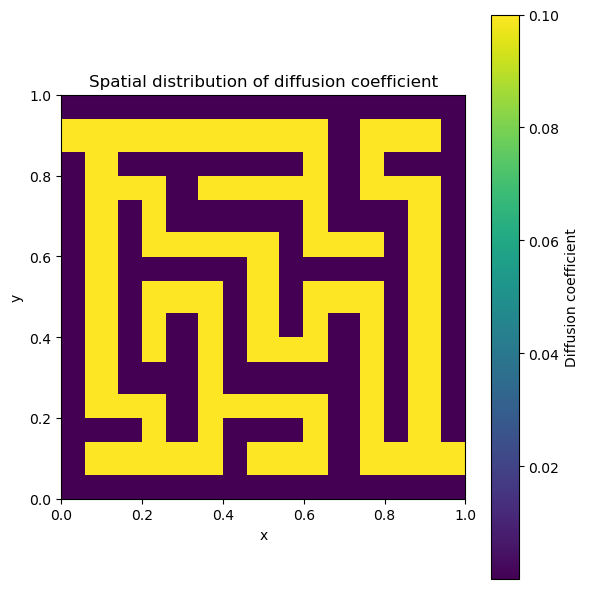

In [5]:
plt.figure(figsize=(6, 6))
plt.imshow(alpha, origin="lower", extent=[0, 1, 0, 1], aspect="equal")
plt.colorbar(label="Diffusion coefficient")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Spatial distribution of diffusion coefficient")
plt.tight_layout()
plt.show()

### Initial and boundary conditions

The initial concentration is

$$
c(x,y,0)=0.
$$

At the inlet on the left boundary, we impose

$$
c(0,y,t)=1, \qquad 0.86 < y < 0.94.
$$

At the outlet on the right boundary, we impose

$$
c(1,y,t)=0, \qquad 0.06 < y < 0.14.
$$

On all other outer boundaries, we impose a no-flux condition:

$$
-\alpha \frac{\partial c}{\partial n}=0,
$$

which is equivalent to

$$
\frac{\partial c}{\partial n}=0.
$$

In [6]:
# Solution array with ghost cells
c = np.zeros((Ny + 2, Nx + 2))  # initial condition c=0
alpha_g = np.zeros((Ny + 2, Nx + 2))
alpha_g[1:Ny+1, 1:Nx+1] = alpha

# Extend alpha to ghost cells
alpha_g[0, 1:Nx+1] = alpha_g[1, 1:Nx+1]
alpha_g[Ny+1, 1:Nx+1] = alpha_g[Ny, 1:Nx+1]
alpha_g[1:Ny+1, 0] = alpha_g[1:Ny+1, 1]
alpha_g[1:Ny+1, Nx+1] = alpha_g[1:Ny+1, Nx]

# Inlet/outlet location
ymin_in, ymax_in = 0.86, 0.94
ymin_out, ymax_out = 0.06, 0.14

c_in = 1.0
c_out = 0.0

inlet_mask = (y > ymin_in) & (y < ymax_in)
outlet_mask = (y > ymin_out) & (y < ymax_out)

### Implementation of the boundary conditions

Dirichlet conditions on a boundary face:

$$
c_{\text{ghost}} = 2c_B - c_{\text{inside}},
$$

For Neumann conditions:

$$
\frac{\partial c}{\partial n}=0,
$$

we copy the adjacent interior value into the ghost cell.

In [7]:
def apply_boundary_conditions(c):
    # Bottom and top: zero flux
    c[0, 1:Nx+1] = c[1, 1:Nx+1]
    c[Ny+1, 1:Nx+1] = c[Ny, 1:Nx+1]

    # Left boundary
    for j in range(1, Ny + 1):
        if inlet_mask[j - 1]:
            c[j, 0] = 2.0 * c_in - c[j, 1]
        else:
            c[j, 0] = c[j, 1]

    # Right boundary
    for j in range(1, Ny + 1):
        if outlet_mask[j - 1]:
            c[j, Nx + 1] = 2.0 * c_out - c[j, Nx]
        else:
            c[j, Nx + 1] = c[j, Nx]

    # Corner values
    c[0, 0] = c[1, 1]
    c[0, Nx+1] = c[1, Nx]
    c[Ny+1, 0] = c[Ny, 1]
    c[Ny+1, Nx+1] = c[Ny, Nx]

In [8]:
# Apply initial boundary conditions
apply_boundary_conditions(c)

#### Visualization of the boundary setup

The figure below shows the maze geometry together with the inlet and outlet segments.

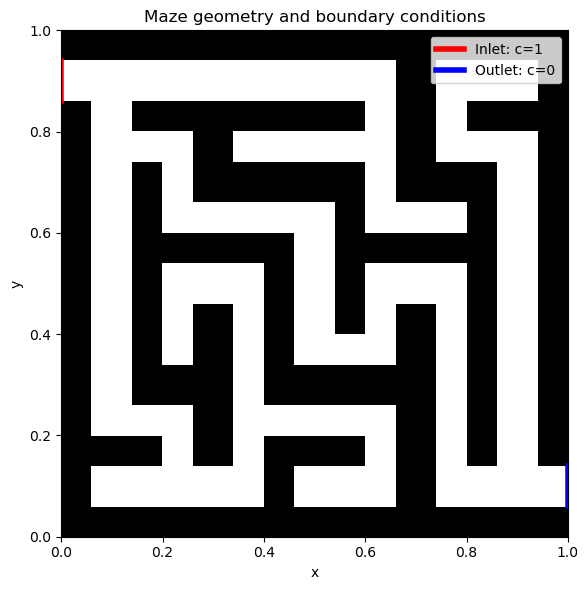

In [9]:
plt.figure(figsize=(6, 6))
plt.imshow(I, origin="lower", extent=[0, 1, 0, 1], cmap="binary", aspect="equal")
plt.plot([0, 0], [ymin_in, ymax_in], color="red", linewidth=4, label="Inlet: c=1")
plt.plot([1, 1], [ymin_out, ymax_out], color="blue", linewidth=4, label="Outlet: c=0")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Maze geometry and boundary conditions")
plt.legend()
plt.tight_layout()
plt.show()